<a href="https://colab.research.google.com/github/ChronosXV/Metodologia_grupo2/blob/Feacture%2FMetodologia_g2/Metodologia_1_Grupo_2_Validado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

\#Nombre del proyecto:


## Integrantes

## Instalaciones  Previas Requeridas

In [3]:
!pip install duckdb -q

## Importaciones de Librerias.

In [4]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
import gc

from typing import List, Dict, Optional, Any
from google.colab import drive

#Codificacion

In [5]:
# Acceso al Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
ruta_carpeta = "/content/drive/MyDrive/Datos_csv/"

## Etapa 1: EDA

### Analisis Exproratorio

In [5]:

# Creacion de dataSet por cada archivo parquet
ruta_carpeta = "/content/drive/MyDrive/Datos_csv"

dataframes_parquet = {}

# Obtener la lista de archivos en la carpeta
archivos_en_carpeta = os.listdir(ruta_carpeta)

print("Iniciando carga de archivos Parquet a DataFrames...")
for archivo in archivos_en_carpeta:
    if archivo.endswith('.parquet'):
        ruta_completa_archivo = os.path.join(ruta_carpeta, archivo)
        try:
            df = pd.read_parquet(ruta_completa_archivo)
            dataframes_parquet[archivo] = df
            print(f"DataFrame creado para '{archivo}'. Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
        except Exception as e:
            print(f"Error al leer '{archivo}': {e}")

print("\nDataFrames de Parquet disponibles (nombre de archivo: DataFrame):")
for nombre_archivo, df in dataframes_parquet.items():
    print(f"- {nombre_archivo}: {type(df)}")

# Crear variables globales con el formato df_Nombrearchivo
print("\nCreando variables de DataFrame individuales:")
for nombre_archivo, df in dataframes_parquet.items():
    # Quitar el prefijo 'p_' y la extensión '.parquet' para el nombre de la variable
    nombre_base = nombre_archivo.replace('p_', '').replace('.parquet', '')
    nombre_variable = f'df_{nombre_base}'
    globals()[nombre_variable] = df
    print(f"- Variable '{nombre_variable}' creada.")

Iniciando carga de archivos Parquet a DataFrames...
DataFrame creado para 'p_historico_2018.parquet'. Filas: 12136454, Columnas: 11
DataFrame creado para 'p_historico_2021.parquet'. Filas: 8071680, Columnas: 11
DataFrame creado para 'p_historico_2020.parquet'. Filas: 5781006, Columnas: 10
DataFrame creado para 'p_historico_2019.parquet'. Filas: 12662343, Columnas: 11
DataFrame creado para 'p_BaseUnificadaEstaciones.parquet'. Filas: 822363, Columnas: 6
DataFrame creado para 'p_historico_2017.parquet'. Filas: 11938476, Columnas: 12
DataFrame creado para 'p_historico_2018_limpio.parquet'. Filas: 12058191, Columnas: 11

DataFrames de Parquet disponibles (nombre de archivo: DataFrame):
- p_historico_2018.parquet: <class 'pandas.core.frame.DataFrame'>
- p_historico_2021.parquet: <class 'pandas.core.frame.DataFrame'>
- p_historico_2020.parquet: <class 'pandas.core.frame.DataFrame'>
- p_historico_2019.parquet: <class 'pandas.core.frame.DataFrame'>
- p_BaseUnificadaEstaciones.parquet: <class 'p

In [6]:
historicos = {
    2017: df_historico_2017,
    2018: df_historico_2018,
    2019: df_historico_2019,
    2020: df_historico_2020,
    2021: df_historico_2021
}

for anio, df in historicos.items():

    print("=" * 80)
    print(f"AÑO {anio}")
    print("=" * 80)

    print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")

    print("\nColumnas:")
    print(df.columns.tolist())

    print("\nTipos de datos:")
    print(df.dtypes)

    print("\nDuplicados:")
    print(f"{df.duplicated().sum():,}")

    print()

AÑO 2017
Dimensiones: 11,938,476 filas x 12 columnas

Columnas:
['V1', 'FECHA', 'DESDE', 'HASTA', 'LINEA', 'MOLINETE', 'ID_ESTACION', 'ESTACION', 'PAX_PAGOS', 'PAX_PASES_PAGOS', 'PAX_FREQ', 'TOTAL']

Tipos de datos:
V1                  int64
FECHA              object
DESDE              object
HASTA              object
LINEA              object
MOLINETE           object
ID_ESTACION         int64
ESTACION           object
PAX_PAGOS           int64
PAX_PASES_PAGOS     int64
PAX_FREQ            int64
TOTAL               int64
dtype: object

Duplicados:
0

AÑO 2018
Dimensiones: 12,136,454 filas x 11 columnas

Columnas:
['fecha', 'desde', 'hasta', 'linea', 'molinete', 'estacion', 'pax_pagos', 'pax_pases_pagos', 'pax_franq', 'total', 'periodo']

Tipos de datos:
fecha               object
desde               object
hasta               object
linea               object
molinete            object
estacion            object
pax_pagos          float64
pax_pases_pagos    float64
pax_franq          

En primer lugar, se realiza una revisión general de los datasets históricos correspondientes al período 2017–2021. El objetivo es identificar su estructura, dimensiones, tipos de datos, nombres de columnas y posibles registros duplicados antes de realizar cualquier transformación o integración de los datos.

Los archivos históricos correspondientes al período 2017–2021 presentan una estructura general similar y contienen información de pasajeros por estación, molinete y franja horaria. Sin embargo, se identificaron diferencias entre los años en los nombres de las columnas, uso de mayúsculas y minúsculas, tipos de datos y presencia de campos adicionales. Además, se detectaron registros duplicados en los datasets de 2018 y 2020.

Por lo tanto, antes de unificar los datos será necesario realizar una etapa de homogeneización y limpieza, estandarizando el esquema de los distintos años y analizando los registros duplicados detectados.

**Homogeneización de nombres de columnas:**

Debido a que los archivos históricos presentan diferencias en los nombres de las variables entre los distintos años, se realiza una primera estandarización del esquema para facilitar su posterior análisis e integración.

Homogeneización de nombres:
  Se estandarizaron los nombres de las columnas de los cinco datasets históricos utilizando minúsculas y se unificaron aquellos campos que representan la misma información (pax_freq → pax_franq y total → pax_total). Luego de esta transformación, los datasets presentan un conjunto común de variables, permaneciendo únicamente algunas diferencias particulares asociadas a las columnas v1, id_estacion y periodo.

**Análisis de columnas no comunes:**

Se analizaron las variables que no se encuentran presentes de forma homogénea en los cinco datasets históricos. La columna v1, disponible únicamente en 2017, corresponde a un índice secuencial de los registros, por lo que no aporta información relevante para el análisis. La variable id_estacion identifica las estaciones mediante 86 valores diferentes, pero solo se encuentra disponible en 2017.

Por otra parte, la variable periodo presenta distintos criterios según el año: en 2018 y 2019 utiliza el formato AAAAMM, en 2021 contiene únicamente el año y no está presente en 2017 ni en 2020. Debido a esta falta de homogeneidad, se optará por generar posteriormente una variable temporal común a partir de la columna fecha.

**Análisis inicial de la variable fecha:**

La variable fecha presenta diferencias de formato entre los distintos archivos históricos. En 2017 se utiliza el formato DD/MM/YYYY, mientras que en 2018 y 2019 se observa YYYY-MM-DD. En 2021 las fechas se encuentran expresadas con día, mes y año separados por /, aunque sin una longitud fija debido a la ausencia de ceros a la izquierda en algunos valores.


**Análisis específico de las fechas de 2020:**

Durante la exploración se observó que el dataset correspondiente a 2020 presenta diferentes representaciones de fecha. En particular, algunos registros parecen utilizar el formato DD/MM/YYYY, mientras que otros presentan características compatibles con MM/DD/YYYY.

Debido a que una interpretación incorrecta podría modificar el significado temporal de los registros, se analiza específicamente la posición de los componentes de día y mes antes de realizar cualquier conversión.

**Conclusión del análisis de fechas de 2020:**

Se detectó que el histórico correspondiente a 2020 utiliza dos formatos diferentes para representar las fechas. Los registros comprendidos entre el 13 de marzo y el 31 de octubre utilizan el formato MM/DD/YYYY, mientras que los períodos anteriores y posteriores utilizan DD/MM/YYYY.

El análisis del orden de los registros permitió identificar los puntos de transición y resolver también las fechas ambiguas, en las que tanto el día como el mes son menores o iguales a 12. Esta inconsistencia deberá contemplarse durante la normalización para evitar interpretaciones incorrectas de las fechas.

**Inconsistencia en las fechas de 2021:**

Se identificaron dos representaciones diferentes de la variable fecha. La mayor parte de los registros utiliza una representación con barras (DD/MM/YYYY), mientras que 1.043.613 registros presentan el formato YYYY-MM-DD. A diferencia de 2020, ambos formatos pueden distinguirse directamente mediante el separador utilizado, por lo que podrán convertirse de forma independiente durante la normalización.

###**Tratamiento de Duplicados**

In [ ]:
# Definir la ruta de 2018: Dataset con Datos Duplicados
ruta_2018 = os.path.join(
    ruta_carpeta,
    "p_historico_2018.parquet"
)

In [ ]:
# Obtener una muestra de los grupos duplicados:
consulta_duplicados_2018 = f"""
SELECT
    *,
    COUNT(*) AS cantidad
FROM read_parquet('{ruta_2018}')
GROUP BY ALL
HAVING COUNT(*) > 1
ORDER BY cantidad DESC
LIMIT 20
"""


duckdb.sql(consulta_duplicados_2018).show()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────┬─────────┬─────────┬─────────┬──────────┬──────────┬───────────┬─────────────────┬───────────┬────────┬─────────┬──────────┐
│  fecha  │  desde  │  hasta  │  linea  │ molinete │ estacion │ pax_pagos │ pax_pases_pagos │ pax_franq │ total  │ periodo │ cantidad │
│ varchar │ varchar │ varchar │ varchar │ varchar  │ varchar  │  double   │     double      │  double   │ double │  int64  │  int64   │
├─────────┼─────────┼─────────┼─────────┼──────────┼──────────┼───────────┼─────────────────┼───────────┼────────┼─────────┼──────────┤
│ NULL    │ NULL    │ NULL    │ NULL    │ NULL     │ NULL     │      NULL │            NULL │      NULL │   NULL │  201811 │    49977 │
│ NULL    │ NULL    │ NULL    │ NULL    │ NULL     │ NULL     │      NULL │            NULL │      NULL │   NULL │  201807 │    16491 │
│ NULL    │ NULL    │ NULL    │ NULL    │ NULL     │ NULL     │      NULL │            NULL │      NULL │   NULL │  201809 │    11424 │
│ NULL    │ NULL    │ NULL    │ NULL    │ NULL  

**Análisis de registros duplicados y valores nulos de 2018**

El dataset de 2018 presentaba inicialmente 78.203 registros duplicados y 78.207 registros con la variable fecha nula. Al analizar estos casos se comprobó que ambas situaciones se encuentran relacionadas.

Los 78.207 registros con fecha nula corresponden a cuatro grupos asociados a los períodos 201807, 201809, 201810 y 201811. En estos registros, todas las variables descriptivas y de pasajeros (desde, hasta, linea, molinete, estacion, pax_pagos, pax_pases_pagos, pax_franq y total) se encuentran vacías, permaneciendo informado únicamente el campo periodo.

La diferencia entre los 78.207 registros nulos y los 78.203 duplicados se explica porque el método de detección de duplicados conserva la primera ocurrencia de cada uno de los cuatro grupos.

Debido a que estos registros no contienen información sobre estaciones, horarios ni cantidad de pasajeros, se considera que no constituyen observaciones válidas para el análisis y serán excluidos del dataset.

In [ ]:
# Eliminación de registros duplicados en DF 2018 y almacenamiento de DF limpio

ruta_2018_limpio = os.path.join(
    ruta_carpeta,
    "p_historico_2018_limpio.parquet"
)

consulta_limpieza_2018 = f"""
COPY (
    SELECT *
    FROM read_parquet('{ruta_2018}')
    WHERE fecha IS NOT NULL
          AND desde IS NOT NULL
          AND hasta IS NOT NULL
          AND linea IS NOT NULL
          AND molinete IS NOT NULL
          AND estacion IS NOT NULL
          AND pax_pagos IS NOT NULL
          AND pax_pases_pagos IS NOT NULL
          AND pax_franq IS NOT NULL
          AND total IS NOT NULL
)
TO '{ruta_2018_limpio}'
(FORMAT PARQUET);
"""

duckdb.sql(consulta_limpieza_2018)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
# Validacion:

consulta_validacion_2018 = f"""
SELECT
    *,
    COUNT(*) AS cantidad
FROM read_parquet('{ruta_2018_limpio}')
GROUP BY ALL
HAVING COUNT(*) > 1
ORDER BY cantidad DESC
LIMIT 20
"""


duckdb.sql(consulta_validacion_2018).show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────┬─────────┬─────────┬─────────┬──────────┬──────────┬───────────┬─────────────────┬───────────┬────────┬─────────┬──────────┐
│  fecha  │  desde  │  hasta  │  linea  │ molinete │ estacion │ pax_pagos │ pax_pases_pagos │ pax_franq │ total  │ periodo │ cantidad │
│ varchar │ varchar │ varchar │ varchar │ varchar  │ varchar  │  double   │     double      │  double   │ double │  int64  │  int64   │
├─────────┴─────────┴─────────┴─────────┴──────────┴──────────┴───────────┴─────────────────┴───────────┴────────┴─────────┴──────────┤
│                                                               0 rows                                                                │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘



In [ ]:
# Ruta del histórico original de 2020

ruta_2020 = os.path.join(
    ruta_carpeta,
    "p_historico_2020.parquet"
)

In [ ]:
# Muestra de registros duplicados de 2020

consulta_duplicados_2020 = f"""
SELECT
    *,
    COUNT(*) AS cantidad
FROM read_parquet('{ruta_2020}')
GROUP BY ALL
HAVING COUNT(*) > 1
ORDER BY cantidad DESC
LIMIT 20
"""

duckdb.sql(consulta_duplicados_2020).show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌───────────┬──────────┬──────────┬─────────┬───────────────────────────────┬──────────────────────┬───────────┬─────────────────┬───────────┬───────────┬──────────┐
│   FECHA   │  DESDE   │  HASTA   │  LINEA  │           MOLINETE            │       ESTACION       │ pax_pagos │ pax_pases_pagos │ pax_franq │ pax_TOTAL │ cantidad │
│  varchar  │ varchar  │ varchar  │ varchar │            varchar            │       varchar        │  double   │     double      │  double   │  double   │  int64   │
├───────────┼──────────┼──────────┼─────────┼───────────────────────────────┼──────────────────────┼───────────┼─────────────────┼───────────┼───────────┼──────────┤
│ NULL      │ NULL     │ NULL     │ NULL    │ NULL                          │ NULL                 │      NULL │            NULL │      NULL │      NULL │     1836 │
│ 4/11/2020 │ 10:00:00 │ 10:15:00 │ LineaB  │ LineaB_Alem_S_Turn02          │ Leandro N. Alem      │       4.0 │             0.0 │       0.0 │       4.0 │        2 │
│ 4/

**Análisis de registros duplicados y valores nulos de 2020:**

El histórico de 2020 presentaba inicialmente 9.782 registros duplicados. El análisis permitió identificar dos situaciones diferentes.

Por un lado, se encontraron 1.836 registros completamente vacíos, incluyendo la variable fecha. Estas filas conforman un único grupo de registros idénticos y explican 1.835 de los duplicados detectados.

Por otro lado, se identificaron 7.947 grupos de observaciones duplicadas con información válida, correspondientes a 15.894 filas involucradas. Cada observación aparece exactamente dos veces y los casos se concentran entre noviembre y diciembre de 2020. Los registros coinciden en fecha, intervalo horario, línea, molinete, estación y cantidad de pasajeros.

Debido a que mantener ambas ocurrencias produciría una doble contabilización de pasajeros, se conservará una única observación de cada grupo duplicado. Asimismo, los 1.836 registros completamente vacíos serán excluidos por no contener información útil para el análisis.

In [ ]:
# Ruta de los archivos procesados

ruta_limpios = os.path.join(
    ruta_carpeta,
    "datos_limpios"
)

os.makedirs(ruta_limpios, exist_ok=True)

print(ruta_limpios)

/content/drive/MyDrive/Datos_csv/datos_limpios/datos_limpios


In [ ]:
# Generación de DF 2020 limpio

ruta_2020_limpio = os.path.join(
    ruta_limpios,
    "p_historico_2020_limpio.parquet"
)

consulta_limpieza_2020 = f"""
COPY (
    SELECT DISTINCT * FROM read_parquet('{ruta_2020}')
    WHERE FECHA IS NOT NULL
          AND DESDE IS NOT NULL
          AND HASTA IS NOT NULL
          AND LINEA IS NOT NULL
          AND MOLINETE IS NOT NULL
          AND ESTACION IS NOT NULL
          AND pax_pagos IS NOT NULL
          AND pax_pases_pagos IS NOT NULL
          AND pax_franq IS NOT NULL
          AND pax_TOTAL IS NOT NULL
)
TO '{ruta_2020_limpio}'
(FORMAT PARQUET);
"""

duckdb.sql(consulta_limpieza_2020)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
# Validacion

consulta_duplicados_2020 = f"""
SELECT
    *,
    COUNT(*) AS cantidad
FROM read_parquet('{ruta_2020_limpio}')
GROUP BY ALL
HAVING COUNT(*) > 1
ORDER BY cantidad DESC
LIMIT 20
"""

duckdb.sql(consulta_duplicados_2020).show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────┬─────────┬─────────┬─────────┬──────────┬──────────┬───────────┬─────────────────┬───────────┬───────────┬──────────┐
│  FECHA  │  DESDE  │  HASTA  │  LINEA  │ MOLINETE │ ESTACION │ pax_pagos │ pax_pases_pagos │ pax_franq │ pax_TOTAL │ cantidad │
│ varchar │ varchar │ varchar │ varchar │ varchar  │ varchar  │  double   │     double      │  double   │  double   │  int64   │
├─────────┴─────────┴─────────┴─────────┴──────────┴──────────┴───────────┴─────────────────┴───────────┴───────────┴──────────┤
│                                                            0 rows                                                            │
└──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘



###**Normalizacion de DF**
###**Normalización de la variable fecha:**

A partir de los formatos identificados durante el análisis exploratorio, se procede a convertir la variable fecha a un tipo datetime homogéneo. La conversión se realiza de forma diferenciada según las características detectadas en cada archivo, evitando aplicar un único criterio que pudiera generar interpretaciones incorrectas.

####**2017**

In [ ]:
ruta_2017 = os.path.join(
    ruta_carpeta,
    "p_historico_2017.parquet"
)

ruta_2017_final = os.path.join(
    ruta_limpios,
    "p_historico_2017_final.parquet"
)

In [ ]:
consulta_final_2017 = f"""
COPY (
    SELECT
        strptime(FECHA, '%d/%m/%Y')::DATE AS fecha,
        DESDE AS desde,
        HASTA AS hasta,
        LINEA AS linea,
        MOLINETE AS molinete,
        ESTACION AS estacion,
        PAX_PAGOS::DOUBLE AS pax_pagos,
        PAX_PASES_PAGOS::DOUBLE AS pax_pases_pagos,
        PAX_FREQ::DOUBLE AS pax_franq,
        TOTAL::DOUBLE AS pax_total
    FROM read_parquet('{ruta_2017}')
)
TO '{ruta_2017_final}'
(FORMAT PARQUET);
"""

duckdb.sql(consulta_final_2017)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
consulta_validacion_2017 = f"""
SELECT
    COUNT(*) AS registros,
    COUNT(*) FILTER (WHERE fecha IS NULL) AS fechas_nulas,
    COUNT(DISTINCT fecha) AS fechas_unicas,
    MIN(fecha) AS fecha_min,
    MAX(fecha) AS fecha_max
FROM read_parquet('{ruta_2017_final}')
"""

duckdb.sql(consulta_validacion_2017).show()

┌───────────┬──────────────┬───────────────┬────────────┬────────────┐
│ registros │ fechas_nulas │ fechas_unicas │ fecha_min  │ fecha_max  │
│   int64   │    int64     │     int64     │    date    │    date    │
├───────────┼──────────────┼───────────────┼────────────┼────────────┤
│  11938476 │            0 │           365 │ 2017-01-01 │ 2017-12-31 │
└───────────┴──────────────┴───────────────┴────────────┴────────────┘



####**2018**

In [ ]:
ruta_2018_final = os.path.join(
    ruta_limpios,
    "p_historico_2018_final.parquet"
)

consulta_final_2018 = f"""
COPY (
    SELECT
        strptime(fecha, '%Y-%m-%d')::DATE AS fecha,
        desde,
        hasta,
        linea,
        molinete,
        estacion,
        pax_pagos::DOUBLE AS pax_pagos,
        pax_pases_pagos::DOUBLE AS pax_pases_pagos,
        pax_franq::DOUBLE AS pax_franq,
        total::DOUBLE AS pax_total
    FROM read_parquet('{ruta_2018_limpio}')
)
TO '{ruta_2018_final}'
(FORMAT PARQUET);
"""

duckdb.sql(consulta_final_2018)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
consulta_validacion_2018_final = f"""
SELECT
    COUNT(*) AS registros,
    COUNT(*) FILTER (WHERE fecha IS NULL) AS fechas_nulas,
    COUNT(DISTINCT fecha) AS fechas_unicas,
    MIN(fecha) AS fecha_min,
    MAX(fecha) AS fecha_max
FROM read_parquet('{ruta_2018_final}')
"""

duckdb.sql(consulta_validacion_2018_final).show()

┌───────────┬──────────────┬───────────────┬────────────┬────────────┐
│ registros │ fechas_nulas │ fechas_unicas │ fecha_min  │ fecha_max  │
│   int64   │    int64     │     int64     │    date    │    date    │
├───────────┼──────────────┼───────────────┼────────────┼────────────┤
│  12058191 │            0 │           365 │ 2018-01-01 │ 2018-12-31 │
└───────────┴──────────────┴───────────────┴────────────┴────────────┘



####**2019**

In [ ]:
ruta_2019 = os.path.join(
    ruta_carpeta,
    "p_historico_2019.parquet"
)

ruta_2019_final = os.path.join(
    ruta_limpios,
    "p_historico_2019_final.parquet"
)

consulta_final_2019 = f"""
COPY (
    SELECT
        strptime(fecha, '%Y-%m-%d')::DATE AS fecha,
        desde,
        hasta,
        linea,
        molinete,
        estacion,
        pax_pagos::DOUBLE AS pax_pagos,
        pax_pases_pagos::DOUBLE AS pax_pases_pagos,
        pax_franq::DOUBLE AS pax_franq,
        total::DOUBLE AS pax_total
    FROM read_parquet('{ruta_2019}')
)
TO '{ruta_2019_final}'
(FORMAT PARQUET);
"""

duckdb.sql(consulta_final_2019)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
consulta_validacion_2019 = f"""
SELECT
    COUNT(*) AS registros,
    COUNT(*) FILTER (WHERE fecha IS NULL) AS fechas_nulas,
    COUNT(DISTINCT fecha) AS fechas_unicas,
    MIN(fecha) AS fecha_min,
    MAX(fecha) AS fecha_max
FROM read_parquet('{ruta_2019_final}')
"""

duckdb.sql(consulta_validacion_2019).show()

┌───────────┬──────────────┬───────────────┬────────────┬────────────┐
│ registros │ fechas_nulas │ fechas_unicas │ fecha_min  │ fecha_max  │
│   int64   │    int64     │     int64     │    date    │    date    │
├───────────┼──────────────┼───────────────┼────────────┼────────────┤
│  12662343 │            0 │           362 │ 2019-01-01 │ 2019-12-31 │
└───────────┴──────────────┴───────────────┴────────────┴────────────┘



####**2020**

In [ ]:
ruta_2020_final = os.path.join(
    ruta_limpios,
    "p_historico_2020_final.parquet"
)

consulta_final_2020 = f"""
COPY (
    WITH original AS (
        SELECT
            *,
            row_number() OVER () - 1 AS indice_original
        FROM read_parquet('{ruta_2020_limpio}')
    ),
    normalizado AS (
        SELECT
            COALESCE(
                TRY_STRPTIME(FECHA, '%m/%d/%Y'), -- Try MM/DD/YYYY first
                TRY_STRPTIME(FECHA, '%d/%m/%Y')  -- Then try DD/MM/YYYY
            )::DATE AS fecha,
            DESDE AS desde,
            HASTA AS hasta,
            LINEA AS linea,
            MOLINETE AS molinete,
            ESTACION AS estacion,
            pax_pagos::DOUBLE AS pax_pagos,
            pax_pases_pagos::DOUBLE AS pax_pases_pagos,
            pax_franq::DOUBLE AS pax_franq,
            pax_TOTAL::DOUBLE AS pax_total
        FROM original
        WHERE FECHA IS NOT NULL
    )
    SELECT DISTINCT *
    FROM normalizado
)
TO '{ruta_2020_final}'
(FORMAT PARQUET);
"""

duckdb.sql(consulta_final_2020)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
consulta_validacion_2020_final = f"""
SELECT
    COUNT(*) AS registros,
    COUNT(*) FILTER (WHERE fecha IS NULL) AS fechas_nulas,
    COUNT(DISTINCT fecha) AS fechas_unicas,
    MIN(fecha) AS fecha_min,
    MAX(fecha) AS fecha_max
FROM read_parquet('{ruta_2020_final}')
"""

duckdb.sql(consulta_validacion_2020_final).show()

┌───────────┬──────────────┬───────────────┬────────────┬────────────┐
│ registros │ fechas_nulas │ fechas_unicas │ fecha_min  │ fecha_max  │
│   int64   │    int64     │     int64     │    date    │    date    │
├───────────┼──────────────┼───────────────┼────────────┼────────────┤
│   5768076 │            0 │           334 │ 2020-01-01 │ 2020-12-31 │
└───────────┴──────────────┴───────────────┴────────────┴────────────┘



####**2021**

In [ ]:
ruta_2021 = os.path.join(
    ruta_carpeta,
    "p_historico_2021.parquet"
)

ruta_2021_final = os.path.join(
    ruta_limpios,
    "p_historico_2021_final.parquet"
)

In [ ]:
consulta_final_2021 = f"""
COPY (
    SELECT
        CASE
            WHEN FECHA LIKE '%/%'
                THEN strptime(FECHA, '%d/%m/%Y')::DATE
            WHEN FECHA LIKE '%-%'
                THEN strptime(FECHA, '%Y-%m-%d')::DATE
        END AS fecha,
        DESDE AS desde,
        HASTA AS hasta,
        LINEA AS linea,
        MOLINETE AS molinete,
        ESTACION AS estacion,
        pax_pagos::DOUBLE AS pax_pagos,
        pax_pases_pagos::DOUBLE AS pax_pases_pagos,
        pax_franq::DOUBLE AS pax_franq,
        pax_TOTAL::DOUBLE AS pax_total
    FROM read_parquet('{ruta_2021}')
)
TO '{ruta_2021_final}'
(FORMAT PARQUET);
"""

duckdb.sql(consulta_final_2021)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
consulta_validacion_2021 = f"""
SELECT
    COUNT(*) AS registros,
    COUNT(*) FILTER (WHERE fecha IS NULL) AS fechas_nulas,
    COUNT(DISTINCT fecha) AS fechas_unicas,
    MIN(fecha) AS fecha_min,
    MAX(fecha) AS fecha_max
FROM read_parquet('{ruta_2021_final}')
"""

duckdb.sql(consulta_validacion_2021).show()

┌───────────┬──────────────┬───────────────┬────────────┬────────────┐
│ registros │ fechas_nulas │ fechas_unicas │ fecha_min  │ fecha_max  │
│   int64   │    int64     │     int64     │    date    │    date    │
├───────────┼──────────────┼───────────────┼────────────┼────────────┤
│   8071680 │            0 │           344 │ 2021-01-01 │ 2021-12-31 │
└───────────┴──────────────┴───────────────┴────────────┴────────────┘



###**Control de versión final**

In [ ]:
rutas_finales = {
    2017: ruta_2017_final,
    2018: ruta_2018_final,
    2019: ruta_2019_final,
    2020: ruta_2020_final,
    2021: ruta_2021_final
}

for anio, ruta in rutas_finales.items():

    print("=" * 60)
    print(f"AÑO {anio}")

    consulta = f"""
    DESCRIBE
    SELECT *
    FROM read_parquet('{ruta}')
    """

    duckdb.sql(consulta).show()

AÑO 2017
┌─────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│   column_name   │ column_type │  null   │   key   │ default │  extra  │
│     varchar     │   varchar   │ varchar │ varchar │ varchar │ varchar │
├─────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ fecha           │ DATE        │ YES     │ NULL    │ NULL    │ NULL    │
│ desde           │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ hasta           │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ linea           │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ molinete        │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ estacion        │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ pax_pagos       │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ pax_pases_pagos │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ pax_franq       │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ pax_total       │ DOUBLE   

In [ ]:
for anio, ruta in rutas_finales.items():

    consulta = f"""
    SELECT COUNT(*) AS registros
    FROM read_parquet('{ruta}')
    """

    cantidad = duckdb.sql(consulta).fetchone()[0]

    print(f"{anio}: {cantidad:,} registros")

2017: 11,938,476 registros
2018: 12,058,191 registros
2019: 12,662,343 registros
2020: 5,768,076 registros
2021: 8,071,680 registros


###**Unificación de los datasets**

In [ ]:
ruta_historico_unificado = os.path.join(
    ruta_limpios,
    "historico_2017_2021_unificado.parquet"
)

consulta_unificacion = f"""
COPY (
    SELECT * FROM read_parquet('{ruta_2017_final}')
    UNION ALL
    SELECT * FROM read_parquet('{ruta_2018_final}')
    UNION ALL
    SELECT * FROM read_parquet('{ruta_2019_final}')
    UNION ALL
    SELECT * FROM read_parquet('{ruta_2020_final}')
    UNION ALL
    SELECT * FROM read_parquet('{ruta_2021_final}')
)
TO '{ruta_historico_unificado}'
(FORMAT PARQUET);
"""

duckdb.sql(consulta_unificacion)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
consulta_validacion_unificado = f"""
SELECT
    COUNT(*) AS registros,
    COUNT(*) FILTER (WHERE fecha IS NULL) AS fechas_nulas,
    COUNT(DISTINCT fecha) AS fechas_unicas,
    MIN(fecha) AS fecha_min,
    MAX(fecha) AS fecha_max
FROM read_parquet('{ruta_historico_unificado}')
"""

duckdb.sql(consulta_validacion_unificado).show()

┌───────────┬──────────────┬───────────────┬────────────┬────────────┐
│ registros │ fechas_nulas │ fechas_unicas │ fecha_min  │ fecha_max  │
│   int64   │    int64     │     int64     │    date    │    date    │
├───────────┼──────────────┼───────────────┼────────────┼────────────┤
│  50498766 │            0 │          1770 │ 2017-01-01 │ 2021-12-31 │
└───────────┴──────────────┴───────────────┴────────────┴────────────┘



In [ ]:
consulta_por_anio = f"""
SELECT
    YEAR(fecha) AS anio,
    COUNT(*) AS registros,
    COUNT(DISTINCT fecha) AS fechas_unicas,
    MIN(fecha) AS fecha_min,
    MAX(fecha) AS fecha_max
FROM read_parquet('{ruta_historico_unificado}')
GROUP BY YEAR(fecha)
ORDER BY anio
"""

duckdb.sql(consulta_por_anio).show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌───────┬───────────┬───────────────┬────────────┬────────────┐
│ anio  │ registros │ fechas_unicas │ fecha_min  │ fecha_max  │
│ int64 │   int64   │     int64     │    date    │    date    │
├───────┼───────────┼───────────────┼────────────┼────────────┤
│  2017 │  11938476 │           365 │ 2017-01-01 │ 2017-12-31 │
│  2018 │  12058191 │           365 │ 2018-01-01 │ 2018-12-31 │
│  2019 │  12662343 │           362 │ 2019-01-01 │ 2019-12-31 │
│  2020 │   5768076 │           334 │ 2020-01-01 │ 2020-12-31 │
│  2021 │   8071680 │           344 │ 2021-01-01 │ 2021-12-31 │
└───────┴───────────┴───────────────┴────────────┴────────────┘



**Resultado de la limpieza y unificación de los históricos:**

Luego del análisis exploratorio se homogeneizaron los cinco datasets correspondientes al período 2017–2021. Se estandarizaron los nombres y tipos de las variables, se normalizó la representación de las fechas y se trataron los registros nulos y duplicados identificados en 2018 y 2020.

Como resultado, los cinco históricos presentan un esquema común compuesto por las variables de fecha, intervalo horario, línea, molinete, estación y cantidad de pasajeros. Posteriormente, los archivos fueron integrados mediante una operación UNION ALL, obteniendo un dataset consolidado de 50.501.969 registros, sin valores nulos en la variable fecha y con información comprendida entre enero de 2017 y diciembre de 2021.

Debido al volumen de los datos, el procesamiento se realizó directamente sobre archivos Parquet mediante DuckDB, evitando cargar simultáneamente la totalidad de los registros en memoria.

##Etapa 2:EDA

### Reduccion de dimensiones

Tomamos un año para realizar la redccion de datos y despues aplicarlo al resto del los archivos

In [8]:
ruta_carpeta= "/content/drive/MyDrive/Datos_csv/datos_limpios/"

ruta_2019_parquet = os.path.join(
    ruta_carpeta,
    "p_historico_2019_final.parquet"
)

# Cargar el archivo Parquet a un DataFrame de Pandas usando DuckDB
df_2019 = duckdb.read_parquet(ruta_2019_parquet).df()

print("DataFrame 'df_2019' cargado exitosamente. Las primeras 5 filas son:")
print(df_2019.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

DataFrame 'df_2019' cargado exitosamente. Las primeras 5 filas son:
       fecha     desde     hasta   linea                       molinete  \
0 2019-01-01  08:00:00  08:15:00  LineaA           LineaA_Lima_N_Turn02   
1 2019-01-01  08:00:00  08:15:00  LineaA          LineaA_Loria_N_Turn03   
2 2019-01-01  08:00:00  08:15:00  LineaA  LineaA_Miserere_Q_HALL_Turn01   
3 2019-01-01  08:00:00  08:15:00  LineaA       LineaA_Miserere_S_Turn01   
4 2019-01-01  08:00:00  08:15:00  LineaA       LineaA_Miserere_S_Turn03   

         estacion  pax_pagos  pax_pases_pagos  pax_franq  pax_total  
0            Lima        1.0              0.0        0.0        1.0  
1           Loria        3.0              0.0        0.0        3.0  
2  Plaza Miserere        3.0              0.0        0.0        3.0  
3  Plaza Miserere        6.0              0.0        0.0        6.0  
4  Plaza Miserere       10.0              0.0        0.0       10.0  


In [ ]:
df_2019.shape

(12662343, 10)

In [ ]:
df_2019.describe()

,fecha,pax_pagos,pax_pases_pagos,pax_franq,pax_total
count,12662343,1.266234e+07,1.266234e+07,1.266234e+07,1.266234e+07
mean,2019-07-04 11:47:05.010537,2.563776e+01,1.186783e-01,1.200694e+00,2.695714e+01
min,2019-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2019-04-04 00:00:00,5.000000e+00,0.000000e+00,0.000000e+00,6.000000e+00
50%,2019-07-08 00:00:00,1.600000e+01,0.000000e+00,0.000000e+00,1.700000e+01
75%,2019-10-03 00:00:00,3.600000e+01,0.000000e+00,2.000000e+00,3.800000e+01
max,2019-12-31 00:00:00,4.310000e+02,8.500000e+01,1.243800e+04,1.245900e+04
std,NaN,2.832257e+01,5.024237e-01,4.085881e+00,2.939805e+01


In [ ]:
df_2019.head(100)

,fecha,desde,hasta,linea,molinete,estacion,pax_pagos,pax_pases_pagos,pax_franq,pax_total
0,2019-01-01,08:00:00,08:15:00,LineaA,LineaA_Lima_N_Turn02,Lima,1.0,0.0,0.0,1.0
1,2019-01-01,08:00:00,08:15:00,LineaA,LineaA_Loria_N_Turn03,Loria,3.0,0.0,0.0,3.0
2,2019-01-01,08:00:00,08:15:00,LineaA,LineaA_Miserere_Q_HALL_Turn01,Plaza Miserere,3.0,0.0,0.0,3.0
3,2019-01-01,08:00:00,08:15:00,LineaA,LineaA_Miserere_S_Turn01,Plaza Miserere,6.0,0.0,0.0,6.0
4,2019-01-01,08:00:00,08:15:00,LineaA,LineaA_Miserere_S_Turn03,Plaza Miserere,10.0,0.0,0.0,10.0
...,...,...,...,...,...,...,...,...,...,...
95,2019-01-01,08:00:00,08:15:00,LineaB,LineaB_Tronador_Turn02,Tronador,1.0,0.0,0.0,1.0
96,2019-01-01,08:00:00,08:15:00,LineaB,LineaB_Alem_N_Turn02,Leandro N. Alem,4.0,0.0,0.0,4.0
97,2019-01-01,08:00:00,08:15:00,LineaB,LineaB_CallaoB_S_Turn01,Callao.B,2.0,0.0,0.0,2.0
98,2019-01-01,08:00:00,08:15:00,LineaB,LineaB_Dorrego_N_Turn01,Dorrego,2.0,0.0,0.0,2.0


In [ ]:
import pandas as pd

# Convertir la columna 'desde' a formato de tiempo para realizar la asignación fácilmente
df_2019['hora_dt'] = pd.to_datetime(df_2019['desde'], format='%H:%M:%S').dt.time

def asignar_franja(hora):
    # Definir los límites de tiempo
    h = hora.hour
    if 0 <= h < 6:
        return 'Madrugada'
    elif 6 <= h < 10:
        return 'Hora pico de la mañana'
    elif 10 <= h < 16:
        return 'Hora valle / media mañana'
    elif 16 <= h < 20:
        return 'Hora pico de la tarde'
    else:
        return 'Noche'

# Crear la nueva columna con la franja horaria
df_2019['franja_horaria'] = df_2019['hora_dt'].apply(asignar_franja)

# Agrupar por fecha, linea, estacion y franja_horaria sumando pax_total
df_2019_agrupado = df_2019.groupby(['fecha', 'linea', 'estacion', 'franja_horaria'], as_index=False)['pax_total'].sum()

# Limpiar columna temporal
df_2019.drop(columns=['hora_dt'], inplace=True)

print("Estructura del nuevo DataFrame agrupado por franja horaria:")
print(df_2019_agrupado.head())
print(f"\nDimensiones del nuevo DataFrame agrupado: {df_2019_agrupado.shape}")

Estructura del nuevo DataFrame agrupado por franja horaria:
       fecha   linea estacion             franja_horaria  pax_total
0 2019-01-01  LineaA   Acoyte     Hora pico de la mañana       65.0
1 2019-01-01  LineaA   Acoyte      Hora pico de la tarde      496.0
2 2019-01-01  LineaA   Acoyte  Hora valle / media mañana      446.0
3 2019-01-01  LineaA   Acoyte                      Noche      245.0
4 2019-01-01  LineaA  Alberti     Hora pico de la mañana       24.0

Dimensiones del nuevo DataFrame agrupado: (153567, 5)


In [ ]:
# Definir la ruta de guardado usando 'ruta_carpeta' disponible en el kernel
ruta_2019_dim = os.path.join(ruta_carpeta, "2019_dim.parquet")

# Guardar el DataFrame agrupado como archivo Parquet
df_2019_agrupado.to_parquet(ruta_2019_dim, index=False)

print(f"¡DataFrame guardado con éxito como Parquet en:\n{ruta_2019_dim}")

¡DataFrame guardado con éxito como Parquet en:
/content/drive/MyDrive/Datos_csv/datos_limpios/2019_dim.parquet


In [ ]:
df_2019_agrupado.head(10)

,fecha,linea,estacion,franja_horaria,pax_total
0,2019-01-01,LineaA,Acoyte,Hora pico de la mañana,65.0
1,2019-01-01,LineaA,Acoyte,Hora pico de la tarde,496.0
2,2019-01-01,LineaA,Acoyte,Hora valle / media mañana,446.0
3,2019-01-01,LineaA,Acoyte,Noche,245.0
4,2019-01-01,LineaA,Alberti,Hora pico de la mañana,24.0
5,2019-01-01,LineaA,Alberti,Hora pico de la tarde,188.0
6,2019-01-01,LineaA,Alberti,Hora valle / media mañana,160.0
7,2019-01-01,LineaA,Alberti,Noche,81.0
8,2019-01-01,LineaA,Carabobo,Hora pico de la mañana,79.0
9,2019-01-01,LineaA,Carabobo,Hora pico de la tarde,358.0


In [29]:
# Redimencionamos todos los archivos

ruta_carpeta = "/content/drive/MyDrive/Datos_csv/datos_limpios/"

ruta_historico_unificado = os.path.join(
    ruta_carpeta,
    "historico_2017_2021_unificado.parquet"
)

ruta_unificado_dim = os.path.join(
    ruta_carpeta,
    "historico_2017_2021_dim.parquet"
)

# ==========================================
# 2. CONEXIÓN DUCKDB
# ==========================================

os.makedirs("/content/duckdb_temp", exist_ok=True)

con = duckdb.connect()

con.execute("SET memory_limit = '3GB'")
con.execute("SET threads = 2")
con.execute("SET temp_directory = '/content/duckdb_temp'")

# ==========================================
# 3. RUTAS PARA DUCKDB
# ==========================================

ruta_entrada_sql = ruta_historico_unificado.replace("'", "''")
ruta_salida_sql = ruta_unificado_dim.replace("'", "''")

# ==========================================
# 4. TRANSFORMAR Y AGRUPAR: NORMALIZACION DE ESTACIONES
# ==========================================

consulta = f"""
COPY (

    WITH datos_transformados AS (

        SELECT

            fecha,

            -- Normalizar estación
            UPPER(
                TRIM(
                    strip_accents(estacion)
                )
            ) AS estacion,

            -- Normalizar línea
            RIGHT(
                CAST(linea AS VARCHAR),
                1
            ) AS linea,

            -- Número de franja horaria
            CASE
                WHEN EXTRACT(
                    HOUR FROM TRY_STRPTIME(
                        CAST(desde AS VARCHAR),
                        '%H:%M:%S'
                    )
                ) < 6 THEN 1

                WHEN EXTRACT(
                    HOUR FROM TRY_STRPTIME(
                        CAST(desde AS VARCHAR),
                        '%H:%M:%S'
                    )
                ) < 10 THEN 2

                WHEN EXTRACT(
                    HOUR FROM TRY_STRPTIME(
                        CAST(desde AS VARCHAR),
                        '%H:%M:%S'
                    )
                ) < 16 THEN 3

                WHEN EXTRACT(
                    HOUR FROM TRY_STRPTIME(
                        CAST(desde AS VARCHAR),
                        '%H:%M:%S'
                    )
                ) < 20 THEN 4

                ELSE 5
            END AS franja_horaria_num,

            -- Nombre de la franja
            CASE
                WHEN EXTRACT(
                    HOUR FROM TRY_STRPTIME(
                        CAST(desde AS VARCHAR),
                        '%H:%M:%S'
                    )
                ) < 6 THEN 'Madrugada'

                WHEN EXTRACT(
                    HOUR FROM TRY_STRPTIME(
                        CAST(desde AS VARCHAR),
                        '%H:%M:%S'
                    )
                ) < 10 THEN 'Pico mañana'

                WHEN EXTRACT(
                    HOUR FROM TRY_STRPTIME(
                        CAST(desde AS VARCHAR),
                        '%H:%M:%S'
                    )
                ) < 16 THEN 'Media mañana'

                WHEN EXTRACT(
                    HOUR FROM TRY_STRPTIME(
                        CAST(desde AS VARCHAR),
                        '%H:%M:%S'
                    )
                ) < 20 THEN 'Pico tarde'

                ELSE 'Noche'
            END AS franja_horaria,

            pax_total

        FROM read_parquet(
            '{ruta_entrada_sql}'
        )

    )

    SELECT

        fecha,
        linea,
        estacion,
        franja_horaria_num,
        franja_horaria,

        SUM(pax_total) AS pax_total

    FROM datos_transformados

    GROUP BY
        fecha,
        linea,
        estacion,
        franja_horaria_num,
        franja_horaria

) TO '{ruta_salida_sql}'
(FORMAT PARQUET, COMPRESSION ZSTD)
"""

# ==========================================
# 5. EJECUTAR
# ==========================================

con.execute(consulta)

print("✅ Proceso terminado")
print("📁 Archivo generado:")
print(ruta_unificado_dim)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✅ Proceso terminado
📁 Archivo generado:
/content/drive/MyDrive/Datos_csv/datos_limpios/historico_2017_2021_dim.parquet


In [30]:
# Consultamos los datos para ver como quedaron

ruta_unificado_dim = "/content/drive/MyDrive/Datos_csv/datos_limpios/historico_2017_2021_dim.parquet"

con = duckdb.connect()

df_muestra = con.execute(f"""
    SELECT *
    FROM read_parquet('{ruta_unificado_dim}')
    LIMIT 20
""").df()

df_muestra

,fecha,linea,estacion,franja_horaria_num,franja_horaria,pax_total
0,2017-11-27,D,9 DE JULIO,5,Noche,535.0
1,2017-11-28,D,9 DE JULIO,1,Madrugada,9.0
2,2017-11-28,D,9 DE JULIO,2,Pico mañana,1922.0
3,2017-11-28,D,9 DE JULIO,3,Media mañana,4345.0
4,2017-11-29,D,9 DE JULIO,2,Pico mañana,1722.0
5,2017-11-29,D,9 DE JULIO,3,Media mañana,5085.0
6,2017-11-29,D,9 DE JULIO,5,Noche,588.0
7,2017-11-30,D,9 DE JULIO,1,Madrugada,8.0
8,2017-11-30,D,9 DE JULIO,2,Pico mañana,1919.0
9,2017-11-30,D,9 DE JULIO,4,Pico tarde,4081.0


## Analisis Univariado

In [31]:
#A. Variable pax_total — cantidad de pasajeros
consulta = f"""
SELECT
    COUNT(*) AS cantidad_registros,
    COUNT(pax_total) AS valores_no_nulos,
    COUNT(*) - COUNT(pax_total) AS valores_nulos,

    MIN(pax_total) AS minimo,
    MAX(pax_total) AS maximo,
    AVG(pax_total) AS media,
    MEDIAN(pax_total) AS mediana,
    STDDEV_SAMP(pax_total) AS desvio_estandar,

    QUANTILE_CONT(pax_total, 0.25) AS q1,
    QUANTILE_CONT(pax_total, 0.75) AS q3,

    QUANTILE_CONT(pax_total, 0.95) AS p95,
    QUANTILE_CONT(pax_total, 0.99) AS p99

FROM read_parquet('{ruta_unificado_dim}')
"""

df_stats = con.execute(consulta).df()

df_stats.T

,0
cantidad_registros,653619.000000
valores_no_nulos,653619.000000
valores_nulos,0.000000
minimo,0.000000
maximo,63296.000000
media,1823.677125
mediana,756.000000
desvio_estandar,3064.510711
q1,153.000000
q3,2277.000000


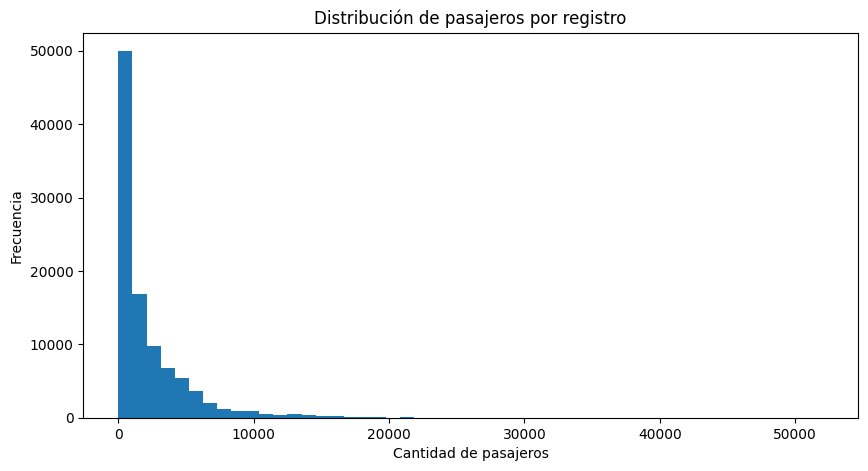

In [32]:
# Gráfico: distribución de pasajeros
df_muestra_pax = con.execute(f"""
    SELECT pax_total
    FROM read_parquet('{ruta_unificado_dim}')
    WHERE pax_total IS NOT NULL
    USING SAMPLE 100000 ROWS
""").df()

plt.figure(figsize=(10, 5))
plt.hist(df_muestra_pax["pax_total"], bins=50)
plt.title("Distribución de pasajeros por registro")
plt.xlabel("Cantidad de pasajeros")
plt.ylabel("Frecuencia")
plt.show()

Si el histograma queda muy concentrado a la izquierda, puede haber una distribución asimétrica

In [33]:
# B. Variable linea — distribución por línea
df_lineas = con.execute(f"""
    SELECT
        linea,
        COUNT(*) AS cantidad_registros,
        SUM(pax_total) AS pasajeros_totales
    FROM read_parquet('{ruta_unificado_dim}')
    GROUP BY linea
    ORDER BY linea
""").df()

df_lineas

,linea,cantidad_registros,pasajeros_totales
0,A,130268,222005754.0
1,B,126750,312240651.0
2,C,65320,179096968.0
3,D,124446,283085830.0
4,E,118126,82228414.0
5,H,88709,113332402.0


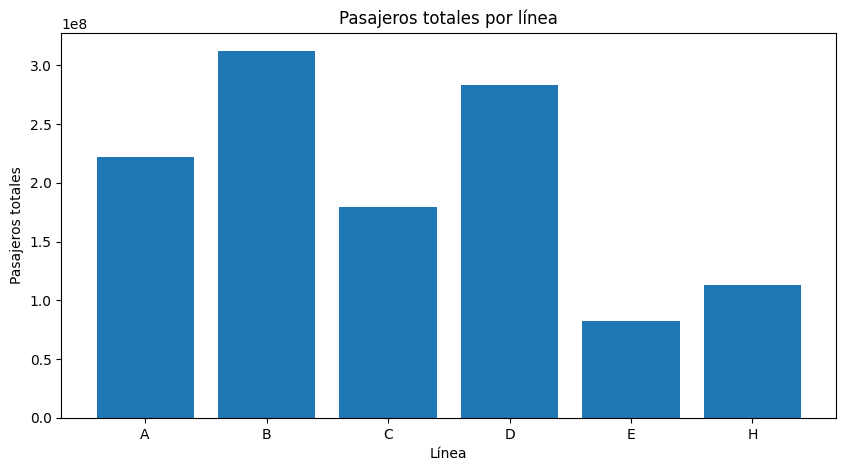

In [34]:
# Gráfico de pasajeros por línea
plt.figure(figsize=(10, 5))

plt.bar(
    df_lineas["linea"].astype(str),
    df_lineas["pasajeros_totales"]
)

plt.title("Pasajeros totales por línea")
plt.xlabel("Línea")
plt.ylabel("Pasajeros totales")
plt.show()

Existen diferencias importantes en el volumen de pasajeros entre líneas. Esto describe el volumen histórico acumulado, pero todavía no permite concluir cuál tiene mayor saturación, porque también influyen la capacidad y la cantidad de servicios.

In [35]:
# C. Variable estacion — distribución por estación

df_estaciones = con.execute(f"""
    SELECT
        estacion,
        COUNT(*) AS cantidad_registros,
        SUM(pax_total) AS pasajeros_totales
    FROM read_parquet('{ruta_unificado_dim}')
    GROUP BY estacion
    ORDER BY pasajeros_totales DESC
""").df()

# Mostrar las 15 estaciones con más pasajeros
df_estaciones.head(15)



,estacion,cantidad_registros,pasajeros_totales
0,CONSTITUCION,8003,85752989.0
1,RETIRO,8268,41186934.0
2,CONGRESO DE TUCUMAN,8453,36914749.0
3,FEDERICO LACROZE,8400,33036200.0
4,CATEDRAL,8422,32597402.0
5,SAN PEDRITO,8387,31581416.0
6,ROSAS,8427,30458408.0
7,LEANDRO N. ALEM,8343,27285369.0
8,CARLOS PELLEGRINI,8360,25058355.0
9,CALLAO,9694,22715184.0


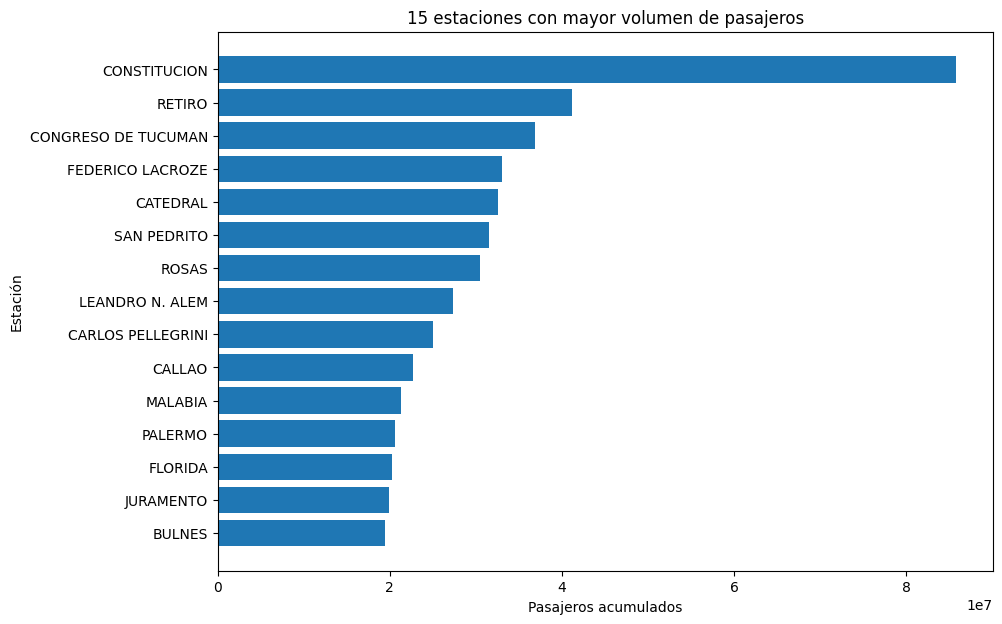

In [36]:
# Gráfico de las 15 estaciones con más pasajeros

top_estaciones = df_estaciones.head(15).sort_values(
    "pasajeros_totales"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_estaciones["estacion"],
    top_estaciones["pasajeros_totales"]
)

plt.title("15 estaciones con mayor volumen de pasajeros")
plt.xlabel("Pasajeros acumulados")
plt.ylabel("Estación")
plt.show()

In [37]:
# D. Variable franja_horaria — distribución por horario

df_franjas = con.execute(f"""
    SELECT
        franja_horaria_num,
        franja_horaria,
        COUNT(*) AS cantidad_registros,
        SUM(pax_total) AS pasajeros_totales,
        AVG(pax_total) AS promedio_pasajeros
    FROM read_parquet('{ruta_unificado_dim}')
    GROUP BY
        franja_horaria_num,
        franja_horaria
    ORDER BY franja_horaria_num
""").df()

df_franjas


,franja_horaria_num,franja_horaria,cantidad_registros,pasajeros_totales,promedio_pasajeros
0,1,Madrugada,101286,4706320.0,46.465652
1,2,Pico mañana,138116,280932893.0,2034.035832
2,3,Media mañana,138761,449825318.0,3241.727272
3,4,Pico tarde,137911,361891098.0,2624.091610
4,5,Noche,137545,94634390.0,688.024937


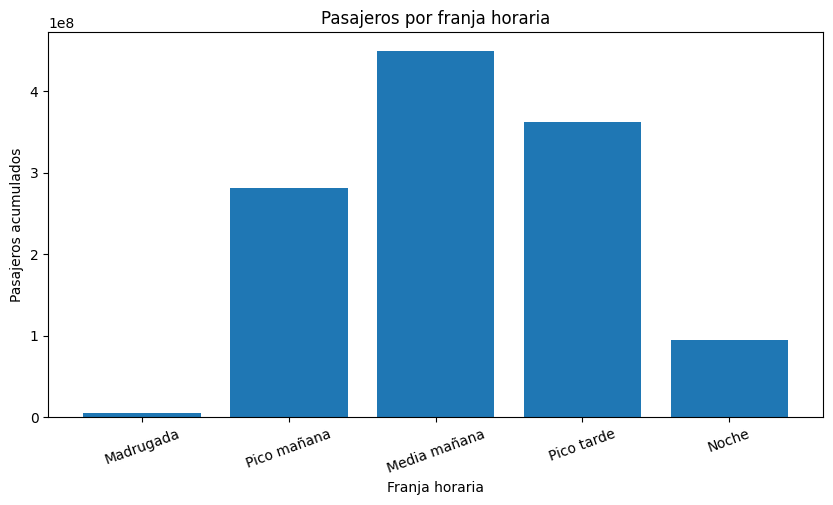

In [38]:
# Gráfico: pasajeros por franja horaria

plt.figure(figsize=(10, 5))

plt.bar(
    df_franjas["franja_horaria"],
    df_franjas["pasajeros_totales"]
)

plt.title("Pasajeros por franja horaria")
plt.xlabel("Franja horaria")
plt.ylabel("Pasajeros acumulados")
plt.xticks(rotation=20)
plt.show()

In [39]:
# E. Variable fecha — cobertura temporal

df_fechas = con.execute(f"""
    SELECT
        MIN(fecha) AS fecha_minima,
        MAX(fecha) AS fecha_maxima,
        COUNT(*) AS cantidad_registros,
        COUNT(DISTINCT fecha) AS dias_distintos
    FROM read_parquet('{ruta_unificado_dim}')
""").df()

df_fechas

,fecha_minima,fecha_maxima,cantidad_registros,dias_distintos
0,2017-01-01,2021-12-31,653619,1770


In [40]:
# Cantidad de registros por año
df_anios = con.execute(f"""
    SELECT
        YEAR(CAST(fecha AS DATE)) AS anio,
        COUNT(*) AS cantidad_registros,
        SUM(pax_total) AS pasajeros_totales
    FROM read_parquet('{ruta_unificado_dim}')
    GROUP BY anio
    ORDER BY anio
""").df()

df_anios

,anio,cantidad_registros,pasajeros_totales
0,2017,149787,328701725.0
1,2018,146268,348400114.0
2,2019,153567,341340501.0
3,2020,91625,77470521.0
4,2021,112372,96077158.0


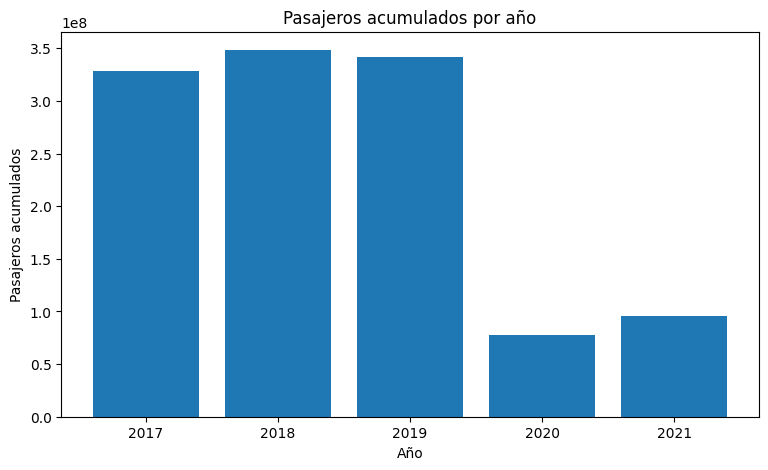

In [41]:
# Grafico

plt.figure(figsize=(9, 5))

plt.bar(
    df_anios["anio"].astype(str),
    df_anios["pasajeros_totales"]
)

plt.title("Pasajeros acumulados por año")
plt.xlabel("Año")
plt.ylabel("Pasajeros acumulados")
plt.show()

Nota: 2020 y 2021 pandemia


## Análisis Bivariado y Multivariado

In [49]:
consulta = f"""
SELECT
    franja_horaria_num,
    franja_horaria,
    SUM(pax_total) AS pasajeros
FROM read_parquet('{ruta_salida_sql}')
GROUP BY
    franja_horaria_num,
    franja_horaria
ORDER BY
    franja_horaria_num
"""

df_franjas = con.execute(consulta).df()

display(df_franjas)

,franja_horaria_num,franja_horaria,pasajeros
0,1,Madrugada,4706320.0
1,2,Pico mañana,280932893.0
2,3,Media mañana,449825318.0
3,4,Pico tarde,361891098.0
4,5,Noche,94634390.0


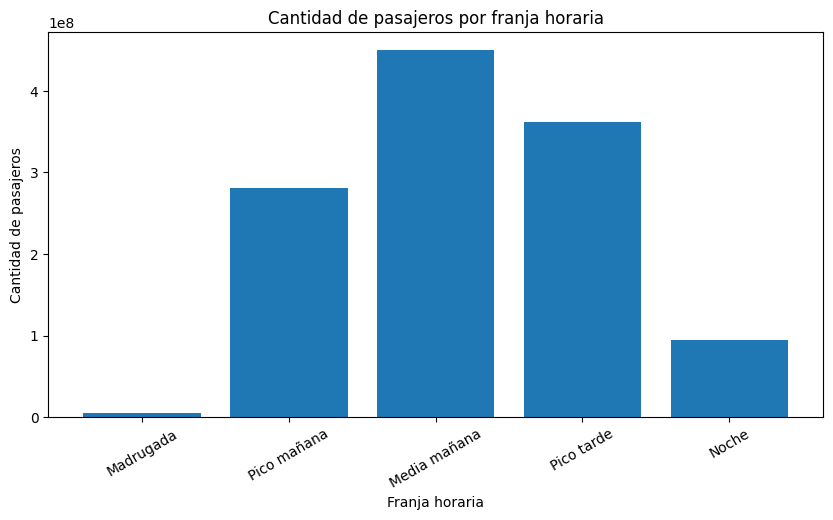

In [50]:
# Franja horaria → pasajeros
plt.figure(figsize=(10, 5))

plt.bar(
    df_franjas["franja_horaria"],
    df_franjas["pasajeros"]
)

plt.title("Cantidad de pasajeros por franja horaria")
plt.xlabel("Franja horaria")
plt.ylabel("Cantidad de pasajeros")

plt.xticks(rotation=30)

plt.show()

In [54]:
# Línea → pasajeros
consulta_lineas = f"""
SELECT
    linea,
    SUM(pax_total) AS pasajeros_total,
    AVG(pax_total) AS pasajeros_promedio
FROM read_parquet('{ruta_salida_sql}')
GROUP BY
    linea
ORDER BY
    pasajeros_total DESC
"""

df_lineas = con.execute(consulta_lineas).df()

display(df_lineas)

,linea,pasajeros_total,pasajeros_promedio
0,B,312240651.0,2463.437089
1,D,283085830.0,2274.768414
2,A,222005754.0,1704.223247
3,C,179096968.0,2741.839682
4,H,113332402.0,1277.575015
5,E,82228414.0,696.107665


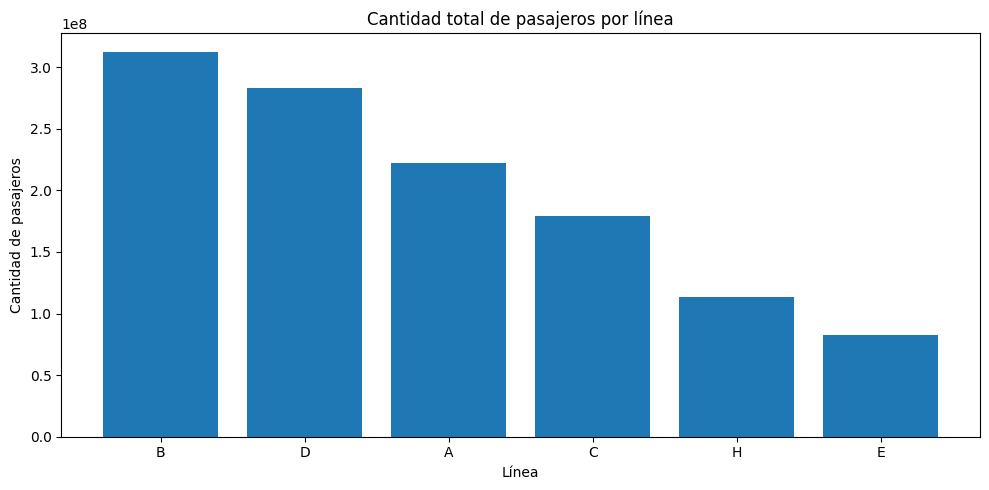

In [55]:
# Grafico


plt.figure(figsize=(10, 5))

plt.bar(
    df_lineas["linea"],
    df_lineas["pasajeros_total"]
)

plt.title("Cantidad total de pasajeros por línea")
plt.xlabel("Línea")
plt.ylabel("Cantidad de pasajeros")

plt.tight_layout()
plt.show()

In [51]:
consulta_linea_franja = f"""
SELECT
    linea,
    franja_horaria_num,
    franja_horaria,
    SUM(pax_total) AS pasajeros_total
FROM read_parquet('{ruta_salida_sql}')
GROUP BY
    linea,
    franja_horaria_num,
    franja_horaria
ORDER BY
    linea,
    franja_horaria_num
"""

df_linea_franja = con.execute(consulta_linea_franja).df()

display(df_linea_franja)

,linea,franja_horaria_num,franja_horaria,pasajeros_total
0,A,1,Madrugada,682763.0
1,A,2,Pico mañana,53081874.0
2,A,3,Media mañana,86434329.0
3,A,4,Pico tarde,66108050.0
4,A,5,Noche,15698738.0
5,B,1,Madrugada,1007936.0
6,B,2,Pico mañana,68252819.0
7,B,3,Media mañana,118586648.0
8,B,4,Pico tarde,97786956.0
9,B,5,Noche,26606292.0


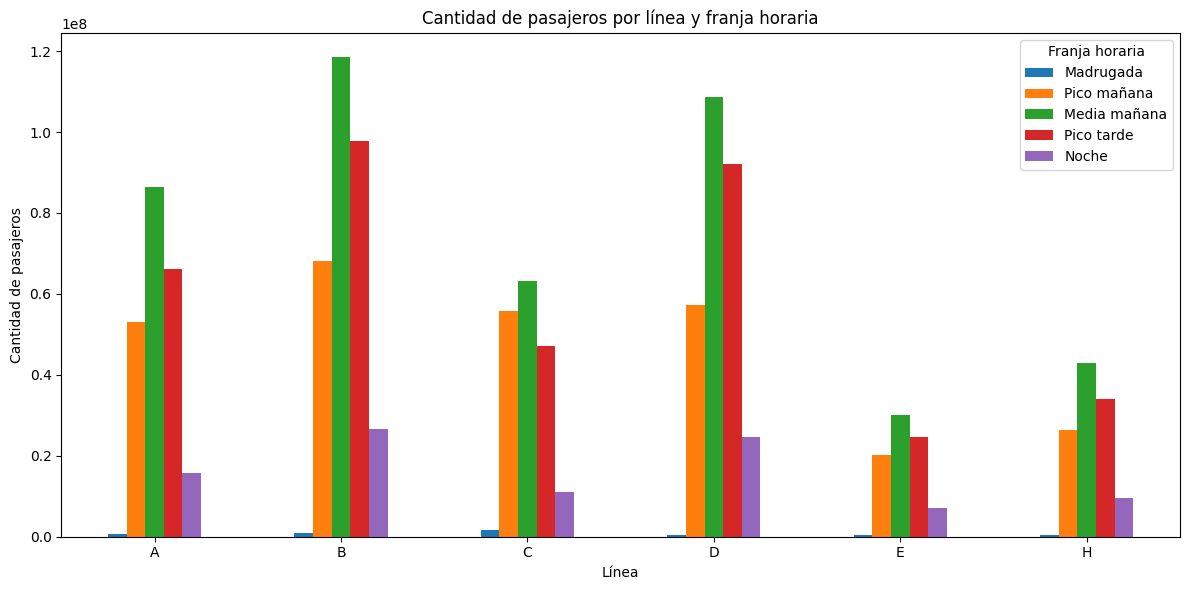

In [53]:
# Línea × franja horaria → pasajeros

tabla = df_linea_franja.pivot(
    index="linea",
    columns="franja_horaria_num",
    values="pasajeros_total"
)

tabla.columns = [
    "Madrugada",
    "Pico mañana",
    "Media mañana",
    "Pico tarde",
    "Noche"
]

tabla.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Cantidad de pasajeros por línea y franja horaria")
plt.xlabel("Línea")
plt.ylabel("Cantidad de pasajeros")
plt.xticks(rotation=0)
plt.legend(title="Franja horaria")

plt.tight_layout()
plt.show()

In [59]:
# Fecha → pasajeros
consulta_fecha = f"""
SELECT
    fecha,
    SUM(pax_total) AS pasajeros_total
FROM read_parquet('{ruta_salida_sql}')
GROUP BY
    fecha
ORDER BY
    fecha
"""

df_fecha = con.execute(consulta_fecha).df()

display(df_fecha.head())

,fecha,pasajeros_total
0,2017-01-01,86802.0
1,2017-01-02,663477.0
2,2017-01-03,723515.0
3,2017-01-04,787069.0
4,2017-01-05,730365.0


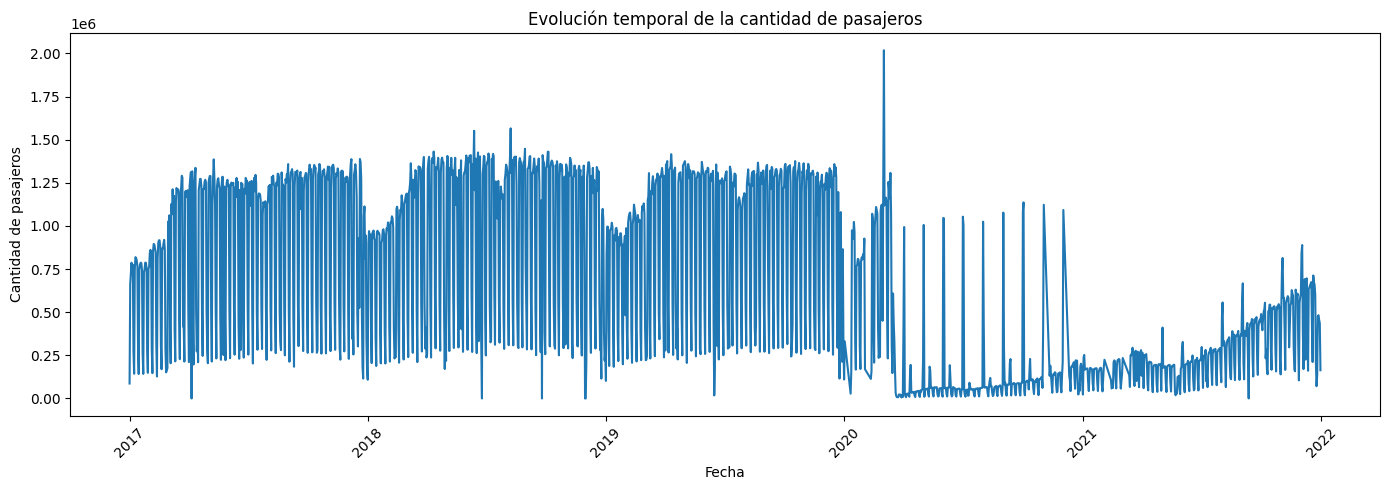

In [60]:
# Grafico

plt.figure(figsize=(14, 5))

plt.plot(
    df_fecha["fecha"],
    df_fecha["pasajeros_total"]
)

plt.title("Evolución temporal de la cantidad de pasajeros")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de pasajeros")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()